# Airbnb Price Prediction

Extending my EDA project - trying to actually predict price instead of just looking at it.
Wanted to see how far I could get with the features already in the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("AB_NYC_2019(3).csv")
df.shape

(48895, 16)

### cleaning

same as before - drop weird prices (0 or crazy high), drop rows missing the important columns.
reviews_per_month is NaN when there are no reviews so just fill with 0, it's not actually missing

In [2]:
df = df[(df['price'] > 0) & (df['price'] < 1000)]
df = df.dropna(subset=['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'availability_365'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df.shape

(48586, 16)

### feature stuff

lat/long by themselves don't really mean anything to a model so I made a distance-from-center
feature instead (just using times square as roughly the center of manhattan, close enough)

also price is super skewed - most listings are cheap but a few are $900+ and mess up the model.
did log(price) instead, standard fix for this

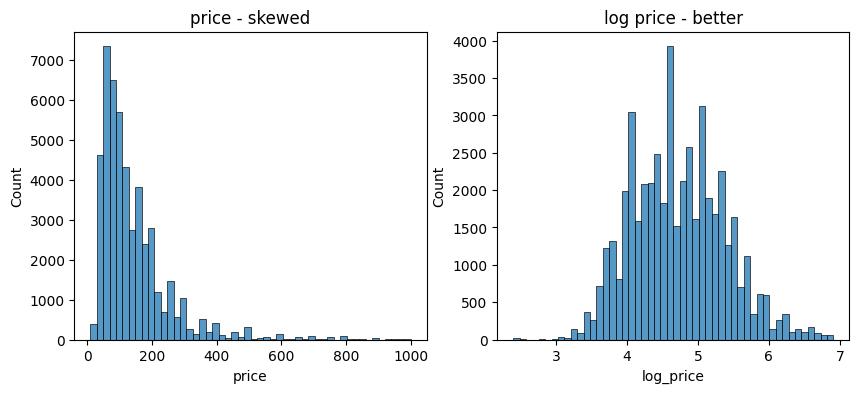

In [3]:
# times square, roughly center of manhattan
center_lat = 40.7580
center_lon = -73.9855
df['distance_from_center'] = np.sqrt((df['latitude']-center_lat)**2 + (df['longitude']-center_lon)**2)

df['log_price'] = np.log1p(df['price'])
df['log_minimum_nights'] = np.log1p(df['minimum_nights'])
df['log_number_of_reviews'] = np.log1p(df['number_of_reviews'])

# quick check that log actually helped the skew
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(df['price'], bins=50, ax=ax[0])
ax[0].set_title('price - skewed')
sns.histplot(df['log_price'], bins=50, ax=ax[1])
ax[1].set_title('log price - better')
plt.show()

In [4]:
features = ['neighbourhood_group', 'room_type', 'log_minimum_nights', 'log_number_of_reviews',
            'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'distance_from_center']
cat_cols = ['neighbourhood_group', 'room_type']
num_cols = [c for c in features if c not in cat_cols]

X = df[features]
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### trying a few models

started with just linear regression as a baseline then tried random forest and gradient boosting
to see if they do better (they usually do on this kind of data since price doesn't move in a
straight line with these features)

also ran 3-fold CV so I'm not just getting a lucky train/test split

In [5]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    log_preds = pipe.predict(X_test)
    preds = np.expm1(log_preds)   # back to actual dollars
    actual = np.expm1(y_test)

    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)
    cv = cross_val_score(pipe, X, y, cv=3, scoring='r2', n_jobs=-1)

    results[name] = {'pipe': pipe, 'mae': mae, 'r2': r2, 'preds': preds, 'actual': actual}
    print(name, '- MAE: $%.2f' % mae, ' R2: %.3f' % r2, ' CV R2: %.3f' % cv.mean())

Linear Regression - MAE: $49.68  R2: 0.328  CV R2: 0.529


Random Forest - MAE: $45.43  R2: 0.426  CV R2: 0.573


Gradient Boosting - MAE: $46.37  R2: 0.400  CV R2: 0.584


random forest won on MAE so using that for the plots below

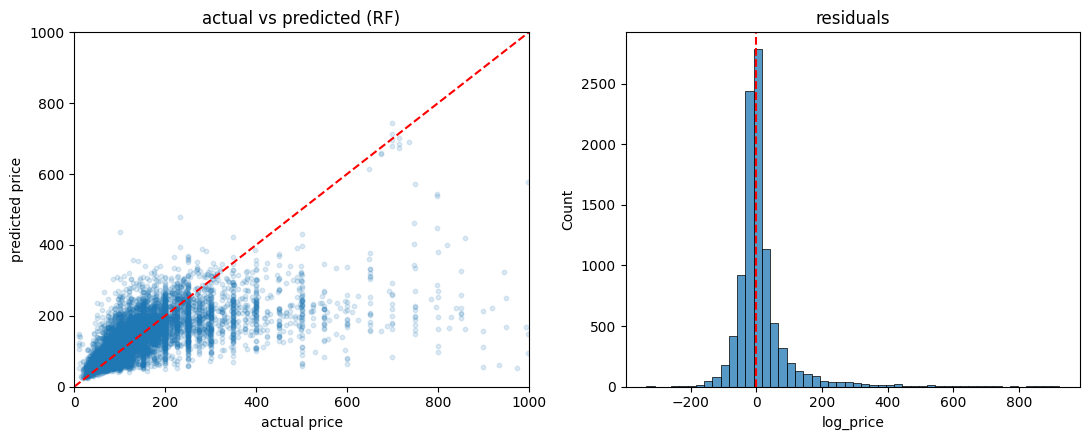

In [6]:
best = results['Random Forest']

fig, ax = plt.subplots(1, 2, figsize=(11,4.5))

ax[0].scatter(best['actual'], best['preds'], alpha=0.15, s=10)
ax[0].plot([0,1000],[0,1000],'r--')
ax[0].set_xlim(0,1000); ax[0].set_ylim(0,1000)
ax[0].set_xlabel('actual price'); ax[0].set_ylabel('predicted price')
ax[0].set_title('actual vs predicted (RF)')

resid = best['actual'] - best['preds']
sns.histplot(resid, bins=50, ax=ax[1])
ax[1].axvline(0, color='r', linestyle='--')
ax[1].set_title('residuals')

plt.tight_layout()
plt.show()

looking at the residual plot the model is decent for normal-priced listings but starts messing up on the expensive ones - makes sense since stuff like photos/host reputation isn't in this dataset at all

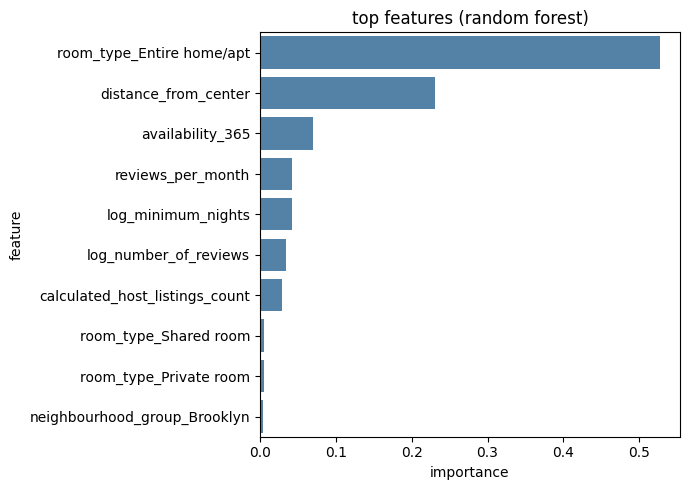

,feature,importance
5,room_type_Entire home/apt,0.527259
13,distance_from_center,0.231150
12,availability_365,0.070037
10,reviews_per_month,0.042030
8,log_minimum_nights,0.041856
9,log_number_of_reviews,0.034738
11,calculated_host_listings_count,0.029033
7,room_type_Shared room,0.005326
6,room_type_Private room,0.005208
1,neighbourhood_group_Brooklyn,0.004300


In [7]:
rf = results['Random Forest']['pipe'].named_steps['model']
ohe = results['Random Forest']['pipe'].named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols

imp_df = pd.DataFrame({'feature': feat_names, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(data=imp_df, y='feature', x='importance', color='steelblue')
plt.title('top features (random forest)')
plt.tight_layout()
plt.show()

imp_df

### notes to self

- random forest did best - MAE $45.43, beat linear regression by a good margin ($49.68)
- room type and distance from center are basically the two biggest things driving price, matches what I saw in the original EDA
- R2 is only ~0.42-0.45 which isn't amazing but that's kind of expected here - a lot of what
  actually drives airbnb price (photos, how the listing is written, host rating) just isn't
  in this dataset, so there's a ceiling on how well any model can do with just these columns
- next thing I'd try if I had more time: pull in text features from the listing name/description,
  might help catch some of what's currently unexplained